In [1]:
"""
We're going to use an Autoencoder to denoise some images from the Fashion-MNIST dataset
28x28x1 images of clothes belonging to 10 different classes
Not doing classification
"""

import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

SEED=42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
"""
Load the data, and we'll add noise in a minute after looking at the images
"""

(X_train_raw, y_train), (X_test_raw, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Class name from the list
class_names = [ "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

X_train = X_train_raw.astype("float32") / 255.0 # Sets the pixel value between 0 and 1
X_test = X_test_raw.astype("float32") / 255.0



# Expand our dimensions by 1 to account for the color channel
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

print(X_train.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28, 1)


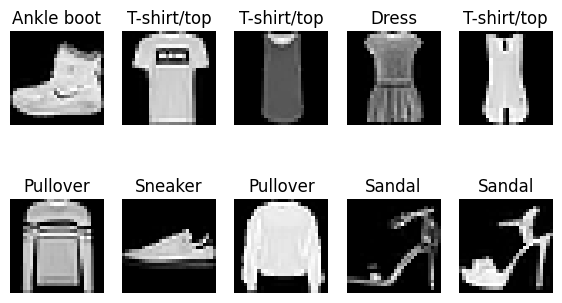

In [3]:
"""
Let's look at some of our data
"""
plt.figure(figsize=(7,4))
for i in range(10):
  plt.subplot(2,5, i+1)
  plt.imshow(X_train[i], cmap="gray")
  plt.title(class_names[y_train[i]])
  plt.axis("off")

plt.show()

In [4]:
"""
Let's add some noise
We're going to add in random pixel values to each pixel to change them slightly
"""

def add_noise(images, noise_factor=.35):
  # Adds a random amount of noise between -1 and 1
  noisy = images + noise_factor * np.random.normal(loc=0, scale=1, size=images.shape)
  # Bounds the image to 0-1 pixel values
  return np.clip(noisy, 0.0, 1.0).astype("float32")

X_train_noisy = add_noise(X_train)
X_test_noise = add_noise(X_test)


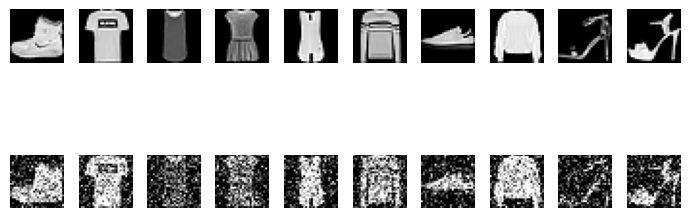

In [5]:
plt.figure(figsize=(7,4))
for i in range(10):
  plt.subplot(2,10, i+1)
  plt.imshow(X_train[i], cmap="gray")
  plt.axis("off")

  plt.subplot(2,10, i+11)
  plt.imshow(X_train_noisy[i], cmap="gray")
  plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
""" Let's build our model

Encoder -> Compresses our image to the most import features
Decoder -> Reconstruct the image
"""

autoencoder= tf.keras.Sequential([
    # Input Layer
    tf.keras.layers.Input(shape=(28,28,1)),

    # Encoder
    tf.keras.layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D((2,2)), # Reduces size by half

    tf.keras.layers.Conv2D(32,  (3,3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D((2,2)),

    # Bottleneck
    # This is basically a small layer in the middle that distills the
    # most important features
    tf.keras.layers.Conv2D(8, (3,3), activation="relu", padding="same"),

    # Decoding
    # Reversing the steps we've done previously
    # We'll add in a new layer called UpSampling
    # Think of this as adding blank pixels and averaging out the existing values
    # Reverse of the pooling effect, will allow the image or feature map to grow in size

    tf.keras.layers.UpSampling2D((2,2)),
    tf.keras.layers.Conv2D(32, (3,3), activation="relu", padding="same"),

    tf.keras.layers.UpSampling2D((2,2)),
    tf.keras.layers.Conv2D(64, (3,3), activation="relu", padding="same"),

    # Output layer
    # Image in image out
    tf.keras.layers.Conv2D(1, (3,3), padding="same", activation="sigmoid")
    # Since our pixel values range from 0-1 we need to give an answer for each
    # pixel between 0 and 1
])

# Compile
autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=.001),
    loss="binary_crossentropy"
    # No Metrics like accuracy because this is unsupervised!
    # We'll look at RECONSTRUCTION ERROR
)

# Summary
autoencoder.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 8)        │         2,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 14, 32)     │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,825 (167.29 KB)

 Trainable params: 42,825 (167.29 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Fit the model
# When training a model to learn anomaly detection
# model.fit(X_input, X_input) -> Training only on normal data

# In our case since we want to de-noise
# model.fit(noisy_images, clean_images aka input)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights = True
    )
]

# Fit the model to the data
history = autoencoder.fit(
    X_train_noisy,
    X_train,
    validation_split=.1,
    epochs=20,
    batch_size=128,
    callbacks=callbacks
)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - loss: 0.3218 - val_loss: 0.2975
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - loss: 0.2916 - val_loss: 0.2907
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2871 - val_loss: 0.2874
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.2844 - val_loss: 0.2854
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.2826 - val_loss: 0.2838
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.2813 - val_loss: 0.2827
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.2804 - val_loss: 0.2819
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2797 - val_loss: 0.2813
Epoch 9/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.2792 - val_loss: 0.2808
Epoch 10/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2787 - val_loss: 0.2803
Epoch 11/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.2783 - val_loss: 0.2800
Epoch 12/20
422/422 ━━━━━━━━━━━━━━━━━━━

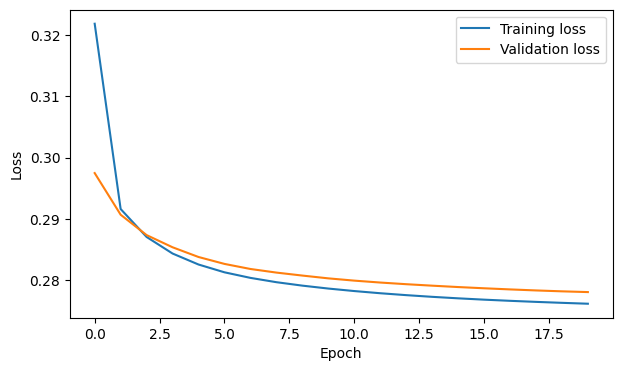

In [13]:
plt.figure(figsize=(7,4))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label = "Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

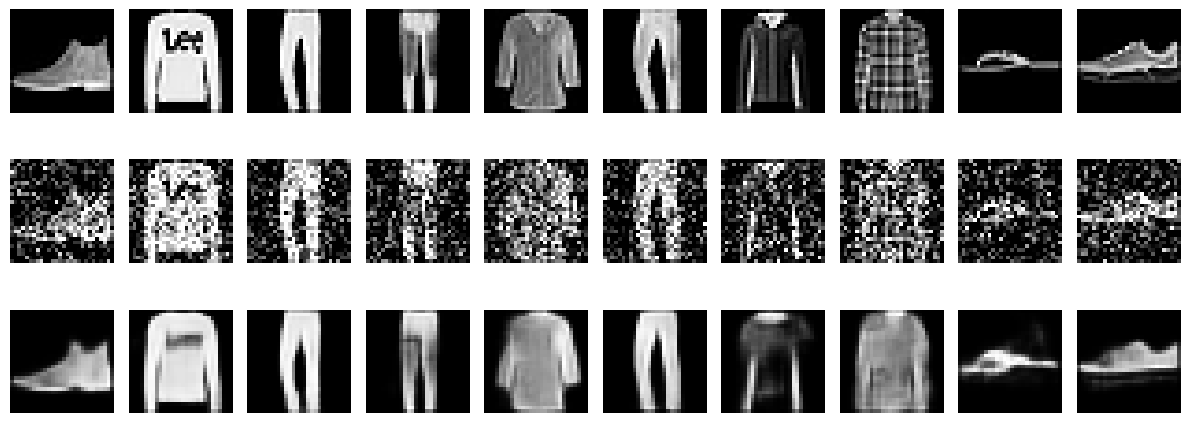

In [14]:
"""
Let's try to visualize some of our reconstructions
We will use the autoencoder to predict some values from the test set
"""

reconstructed = autoencoder.predict(X_test_noise[:10], verbose=0)

# Plot everthing
plt.figure(figsize=(12,5))
for i in range(10):
  # Clean Data
  plt.subplot(3,10, i+1)
  plt.imshow(X_test[i], cmap="gray")
  plt.axis("off")

  # Noisy Data
  plt.subplot(3,10, i+11)
  plt.imshow(X_test_noise[i], cmap="gray")
  plt.axis("off")

  # Reconstructed
  plt.subplot(3,10, i+21)
  plt.imshow(reconstructed[i], cmap="gray")
  plt.axis("off")

plt.tight_layout()
plt.show()

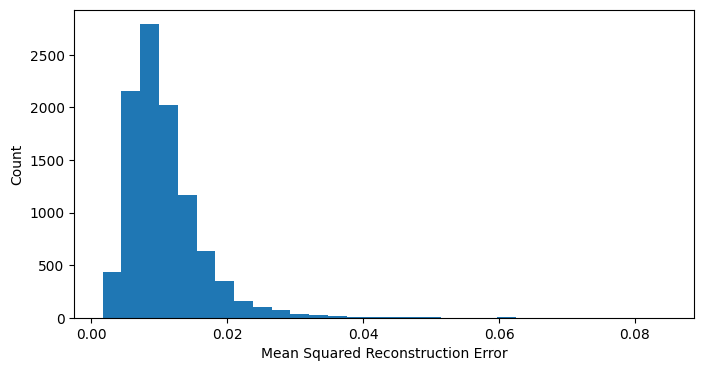

Mean reconstruction error: 0.010768529
Max reconstruction error: 0.08459521


In [16]:
"""
Plot our reconstruction error

Recall reconstruction error is the big metric here
If we're anomaly detection you'll take "normal" values and try to reconstruct
them. If you ever get anything that is getting reconstructed improperly (high
reconstruction error), it usually an anomaly
"""

test_reconstructed = autoencoder(X_test_noise[:10000], verbose=0)
# Calculate the mean error
errors = np.mean((X_test[:10000] - test_reconstructed) ** 2, axis=(1,2,3))

# Plot a histogram of our errors to see how they shape out
plt.figure(figsize=(8,4))
plt.hist(errors, bins=30)
plt.xlabel("Mean Squared Reconstruction Error")
plt.ylabel("Count")

plt.show()

print("Mean reconstruction error:", errors.mean())
print("Max reconstruction error:", errors.max())